<a href="https://colab.research.google.com/github/Navjotkhatri/E-Commerce-Customer-Satisfaction-Score-Prediction/blob/main/E_Commerce_Customer_Satisfaction_Score_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - E-Commerce Customer Satisfaction Score Prediction


multi-class classification.

# **Project Summary -**

This project focuses on predicting Customer Satisfaction (CSAT) scores using Deep Learning Artificial Neural Networks (ANN). In the context of e-commerce, understanding customer satisfaction through their interactions and feedback is crucial for enhancing service quality, customer retention, and overall business growth. By leveraging advanced neural network models, we aim to accurately forecast CSAT scores based on a myriad of interaction-related features, providing actionable insights for service improvement.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


The primary goal of this project is to develop a deep learning model that can accurately predict the CSAT scores based on customer interactions and feedback. By doing so, we aim to provide e-commerce businesses with a powerful tool to monitor and enhance customer satisfaction in real-time, thereby improving service quality and fostering customer loyalty.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [347]:

# Import Libraries

import numpy as np
import pandas as pd
import datetime as dt

## Statistics Library
import scipy.stats as stats

## Data Visualisation Libraray
import matplotlib.pyplot as plt
import pylab
import seaborn as sns

## Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

## Importing essential libraries to check the accuracy
from sklearn import metrics
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

## Warnings
import warnings
warnings.filterwarnings('ignore')

In [348]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import r2_score
from math import sqrt
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from prettytable import PrettyTable

### Dataset Loading

In [349]:
# Load Dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [350]:
# Load Dataset

df=pd.read_csv("/content/drive/MyDrive/ML Engineer/proj 4 E-Commerce Customer Satisfaction Score Prediction/eCommerce_Customer_support_data.csv")

### Dataset First View

In [351]:
# Dataset First Look
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [352]:
df.tail()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
85902,505ea5e7-c475-4fac-ac36-1d19a4cb610f,Inbound,Refund Related,Refund Enquiry,NaN,1b5a2b9c-a95f-405f-a42e-5b1b693f3dc9,NaN,30/08/2023 23:20,31/08/2023 07:22,31-Aug-23,NaN,NaN,NaN,NaN,Brandon Leon,Ethan Tan,William Kim,On Job Training,Morning,4
85903,44b38d3f-1523-4182-aba2-72917586647c,Inbound,Order Related,Seller Cancelled Order,Supported team customer executive good,d0e8a817-96d5-4ace-bb82-adec50398e22,NaN,31/08/2023 08:15,31/08/2023 08:17,31-Aug-23,NaN,NaN,NaN,NaN,Linda Foster,Noah Patel,Emily Chen,>90,Morning,5
85904,723bce2c-496c-4aa8-a64b-ca17004528f0,Inbound,Order Related,Order status enquiry,need to improve with proper details.,bdefe788-ccec-4eda-8ca4-51045e68db8a,NaN,31/08/2023 18:57,31/08/2023 19:02,31-Aug-23,NaN,NaN,NaN,NaN,Kimberly Martinez,Aiden Patel,Olivia Tan,On Job Training,Evening,5
85905,707528ee-6873-4192-bfa9-a491f1c08ab5,Inbound,Feedback,UnProfessional Behaviour,NaN,a031ec28-0c5e-450e-95b2-592342c40bc4,NaN,31/08/2023 19:59,31/08/2023 20:00,31-Aug-23,NaN,NaN,NaN,NaN,Daniel Martin,Olivia Suzuki,Olivia Tan,>90,Morning,4
85906,07c7a878-0d5a-42e0-97ef-de59abec0238,Inbound,Returns,Reverse Pickup Enquiry,NaN,3230db30-f8da-4c44-8636-ec76d1d3d4f3,NaN,31/08/2023 23:36,31/08/2023 23:37,31-Aug-23,NaN,NaN,NaN,NaN,Elizabeth Guerra,Nathan Patel,Jennifer Nguyen,On Job Training,Evening,5


### Dataset Rows & Columns count

In [353]:
# Dataset Rows & Columns count

df.shape

(85907, 20)

### Dataset Information

In [354]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

#### Duplicate Values

In [355]:
# Dataset Duplicate Value Count

df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [356]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
Unique id,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,57165
Order_id,18232
order_date_time,68693
Issue_reported at,0
issue_responded,0
Survey_response_Date,0


<Axes: >

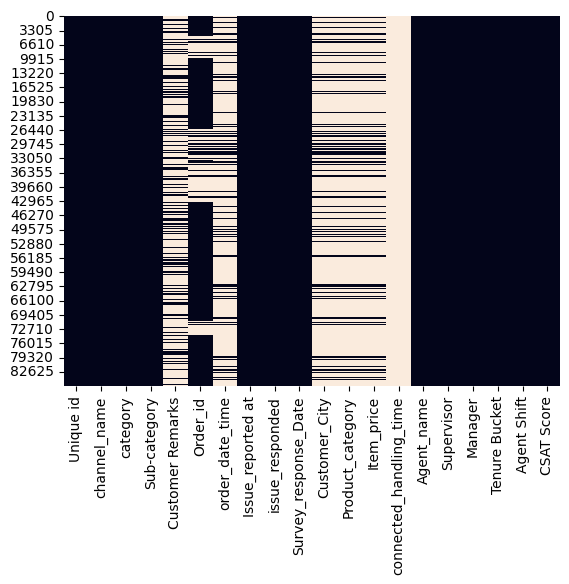

In [357]:
# Visualizing the missing values
sns.heatmap(df.isnull(), cbar=False)

### What did you know about your dataset?

The dataset contains 85,907 customer service interaction records with 20 features, including categorical, numerical, text, and datetime data. The target variable is CSAT Score, making it a multi-class classification problem. Initial exploration also revealed significant missing values in several columns, requiring data cleaning and preprocessing before model training.


## ***2. Understanding Your Variables***

In [358]:
# Dataset Columns
df.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')

In [359]:
# Dataset Describe
df.describe(include='all')

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
count,85907,85907,85907,85907,28742,67675,17214,85907,85907,85907,17079,17196,17206.000000,242.000000,85907,85907,85907,85907,85907,85907.000000
unique,85907,3,12,57,18231,67675,13766,30923,30262,31,1782,9,NaN,NaN,1371,40,6,5,5,NaN
top,07c7a878-0d5a-42e0-97ef-de59abec0238,Inbound,Returns,Reverse Pickup Enquiry,Good,3230db30-f8da-4c44-8636-ec76d1d3d4f3,09/08/2023 11:55,13/08/2023 10:40,28/08/2023 00:00,28-Aug-23,HYDERABAD,Electronics,NaN,NaN,Wendy Taylor,Carter Park,John Smith,>90,Morning,NaN
freq,1,68142,44097,22389,1390,1,7,13,3378,3452,722,4706,NaN,NaN,429,4273,25261,30660,41426,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5660.774846,462.400826,NaN,NaN,NaN,NaN,NaN,4.242157
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12825.728411,246.295037,NaN,NaN,NaN,NaN,NaN,1.378903
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,392.000000,293.000000,NaN,NaN,NaN,NaN,NaN,4.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,979.000000,427.000000,NaN,NaN,NaN,NaN,NaN,5.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2699.750000,592.250000,NaN,NaN,NaN,NaN,NaN,5.000000


### Variables Description

The dataset contains 20 variables, including customer interaction details, order information, agent details, timestamps, and customer feedback. The target variable is CSAT Score, while the remaining features serve as predictor variables for training the deep learning model.

### Check Unique Values for each variable.

In [360]:
# Check Unique Values for each variable.
for i in df.columns.tolist():
  print("No. of unique values in ",i,"is",df[i].nunique(),".")

No. of unique values in  Unique id is 85907 .
No. of unique values in  channel_name is 3 .
No. of unique values in  category is 12 .
No. of unique values in  Sub-category is 57 .
No. of unique values in  Customer Remarks is 18231 .
No. of unique values in  Order_id is 67675 .
No. of unique values in  order_date_time is 13766 .
No. of unique values in  Issue_reported at is 30923 .
No. of unique values in  issue_responded is 30262 .
No. of unique values in  Survey_response_Date is 31 .
No. of unique values in  Customer_City is 1782 .
No. of unique values in  Product_category is 9 .
No. of unique values in  Item_price is 2789 .
No. of unique values in  connected_handling_time is 211 .
No. of unique values in  Agent_name is 1371 .
No. of unique values in  Supervisor is 40 .
No. of unique values in  Manager is 6 .
No. of unique values in  Tenure Bucket is 5 .
No. of unique values in  Agent Shift is 5 .
No. of unique values in  CSAT Score is 5 .


## 3. ***Data Wrangling***

### Data Wrangling Code

In [361]:
# Write your code to make your dataset analysis ready.
drop_cols = [
    'Unique id',
    'Order_id',
    'order_date_time',
    'Customer_City',
    'Product_category',
    'Item_price',
    'connected_handling_time'
]

df.drop(columns=drop_cols, inplace=True)

print(df.shape)
df.head()

(85907, 13)


,channel_name,category,Sub-category,Customer Remarks,Issue_reported at,issue_responded,Survey_response_Date,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,Outcall,Product Queries,Life Insurance,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,Outcall,Product Queries,Product Specific Information,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,Inbound,Order Related,Installation/demo,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,Inbound,Returns,Reverse Pickup Enquiry,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,Inbound,Cancellation,Not Needed,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [362]:
df.isnull().sum()

,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,57165
Issue_reported at,0
issue_responded,0
Survey_response_Date,0
Agent_name,0
Supervisor,0
Manager,0


In [363]:
df['Customer Remarks'] = df['Customer Remarks'].fillna('No Remarks')

In [364]:
date_cols = [
    'Issue_reported at',
    'issue_responded',
    'Survey_response_Date'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)

In [365]:
df['Response_Time_Minutes'] = (
    df['issue_responded'] - df['Issue_reported at']
).dt.total_seconds() / 60

In [366]:
df[['Issue_reported at',
    'issue_responded',
    'Response_Time_Minutes']].head()

,Issue_reported at,issue_responded,Response_Time_Minutes
0,2023-08-01 11:13:00,2023-08-01 11:47:00,34.0
1,2023-08-01 12:52:00,2023-08-01 12:54:00,2.0
2,2023-08-01 20:16:00,2023-08-01 20:38:00,22.0
3,2023-08-01 20:56:00,2023-08-01 21:16:00,20.0
4,2023-08-01 10:30:00,2023-08-01 10:32:00,2.0


### What all manipulations have you done and insights you found?

During data wrangling, unnecessary identifier columns and features with excessive missing values were removed, missing values in **Customer Remarks** were handled, and date columns were converted into datetime format. Additionally, a new **Response Time** feature was created, resulting in a clean, analysis-ready dataset with no missing values in the retained features.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 Target Variable Distribution (CSAT Score)

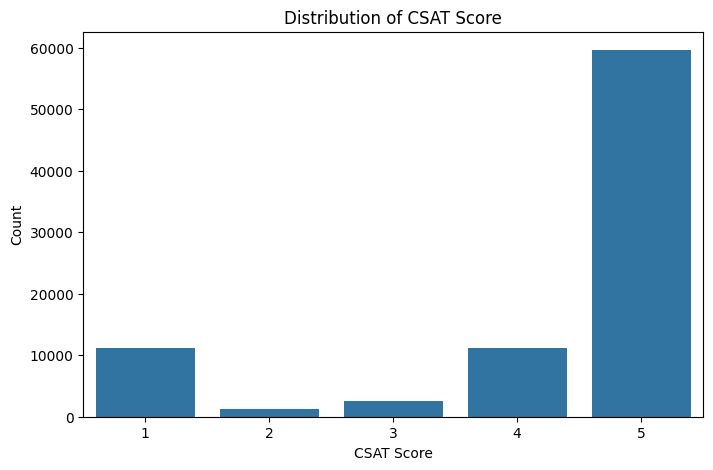

In [367]:
# Chart - 1 visualization code

plt.figure(figsize=(8,5))

sns.countplot(data=df, x='CSAT Score')

plt.title("Distribution of CSAT Score")
plt.xlabel("CSAT Score")
plt.ylabel("Count")

plt.show()

##### 1. Why did you pick the specific chart?

A count plot was chosen because the target variable (CSAT Score) is categorical. It helps visualize the frequency of each satisfaction level and identify whether the dataset is balanced or imbalanced before model training.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that CSAT Score 5 is the most frequent class by a large margin, while scores 2 and 3 occur much less often. This indicates that the dataset is highly imbalanced, with most customers reporting very high satisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The insights help the business identify that most customers are satisfied, reflecting generally good service quality. However, the strong class imbalance may negatively affect the predictive model, as it could become biased toward predicting CSAT Score 5 more often. Appropriate techniques such as class weighting or oversampling should be considered to improve model performance across all satisfaction levels.

#### Chart - 2 Channel-wise Customer Interactions

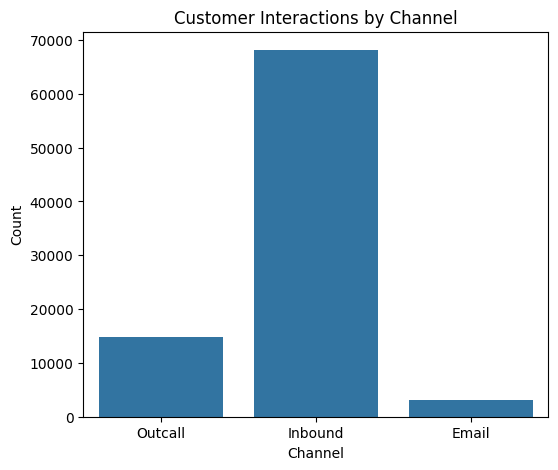

In [368]:
# Chart - 2 visualization code

plt.figure(figsize=(6,5))

sns.countplot(data=df, x='channel_name')

plt.title("Customer Interactions by Channel")
plt.xlabel("Channel")
plt.ylabel("Count")

plt.show()

##### 1. Why did you pick the specific chart?

A count plot was used to visualize the distribution of customer interactions across different service channels. It provides a clear comparison of the volume of interactions handled through each channel.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that the Inbound channel handles the majority of customer interactions, while Outcall accounts for a moderate number of interactions and Email has the fewest. This indicates that customers primarily rely on inbound support for resolving their issues.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help the business allocate more agents and resources to the Inbound channel to improve service efficiency and reduce response times. However, the heavy dependence on a single channel may lead to longer wait times during peak periods, which could negatively impact customer satisfaction if not managed effectively.

#### Chart - 3 Category Distribution

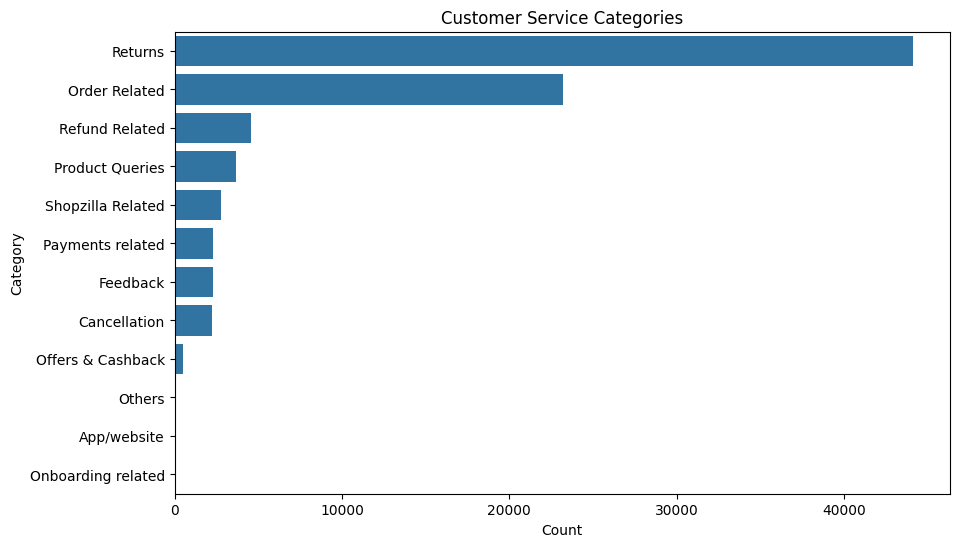

In [369]:
# Chart - 3 visualization code

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y='category',
    order=df['category'].value_counts().index
)

plt.title("Customer Service Categories")
plt.xlabel("Count")
plt.ylabel("Category")

plt.show()

##### 1. Why did you pick the specific chart?

A horizontal count plot was selected to compare the frequency of customer interactions across different service categories. It makes it easy to identify the most and least common issues handled by the customer support team.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that Returns is the most common customer service category, followed by Order Related and Refund Related issues. Categories such as App/Website, Onboarding Related, and Others have very few interactions, indicating that customer concerns are concentrated around post-purchase services.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights help the business prioritize improvements in the Returns and Order Related processes, which can significantly enhance customer satisfaction and reduce support requests. However, the high volume of return-related issues may indicate operational challenges such as product quality, delivery problems, or unclear return policies, which could negatively affect customer experience and increase operational costs if not addressed.

#### Chart - 4 Top 10 Sub-Categories

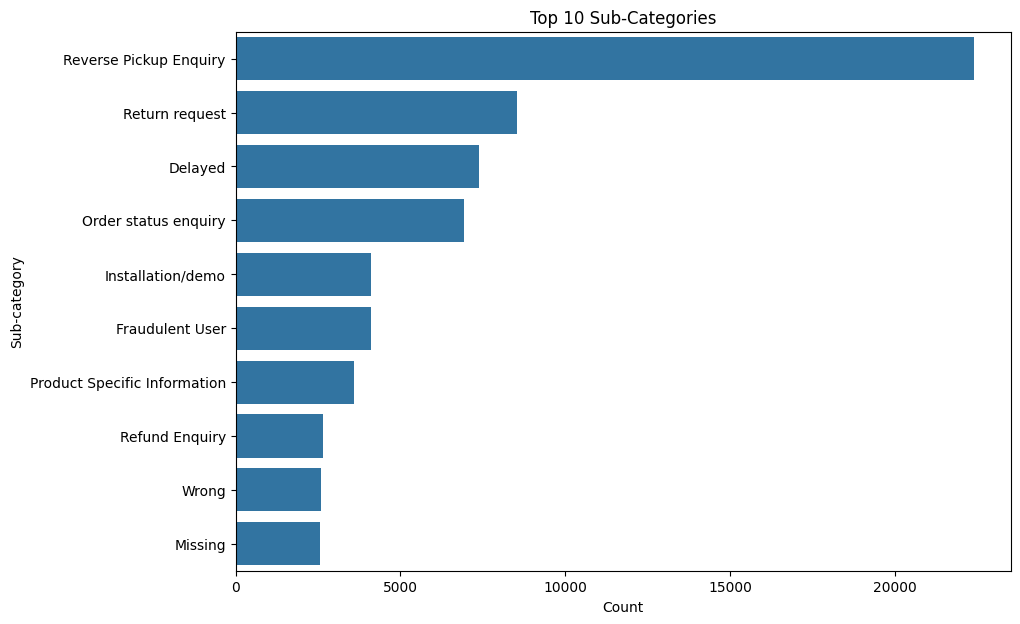

In [370]:
# Chart - 4 visualization code

plt.figure(figsize=(10,7))

top_sub = df['Sub-category'].value_counts().head(10)

sns.barplot(
    x=top_sub.values,
    y=top_sub.index
)

plt.title("Top 10 Sub-Categories")
plt.xlabel("Count")
plt.ylabel("Sub-category")

plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart was used to display the top 10 customer issue sub-categories because it provides a clear comparison of the most frequently reported issues. It helps identify the specific problems that generate the highest volume of customer support requests.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that Reverse Pickup Enquiry is by far the most common customer issue, followed by Return Request, Delayed, and Order Status Enquiry. This indicates that most customer concerns are related to the order fulfillment and returns process rather than product information or payment issues.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights enable the business to focus on improving the reverse pickup and return process, which can reduce customer complaints and improve overall satisfaction. However, the high number of reverse pickup and delay-related enquiries suggests operational inefficiencies in the logistics and return process, which may increase customer dissatisfaction and negatively impact repeat purchases if not resolved.

#### Chart - 5 Agent Shift Distribution

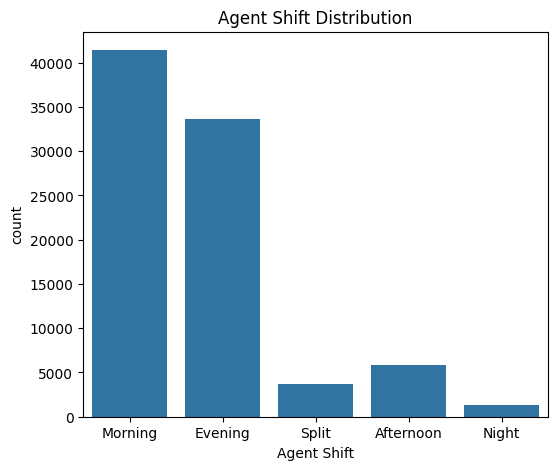

In [371]:
# Chart - 5 visualization code

plt.figure(figsize=(6,5))

sns.countplot(data=df, x='Agent Shift')

plt.title("Agent Shift Distribution")

plt.show()

##### 1. Why did you pick the specific chart?

A count plot was chosen to compare the number of customer interactions handled across different agent shifts. It helps identify workload distribution and staffing patterns throughout the day.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that the Morning shift handles the highest number of customer interactions, followed by the Evening shift. In contrast, the Afternoon, Split, and Night shifts receive significantly fewer interactions, indicating that customer support demand is concentrated during the daytime.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help the business optimize workforce planning by assigning more agents to the Morning and Evening shifts, where demand is highest. However, if staffing during these peak shifts is insufficient, it may result in longer response times and reduced customer satisfaction, ultimately affecting service quality and customer retention.

#### Chart - 6 Tenure Bucket Distribution

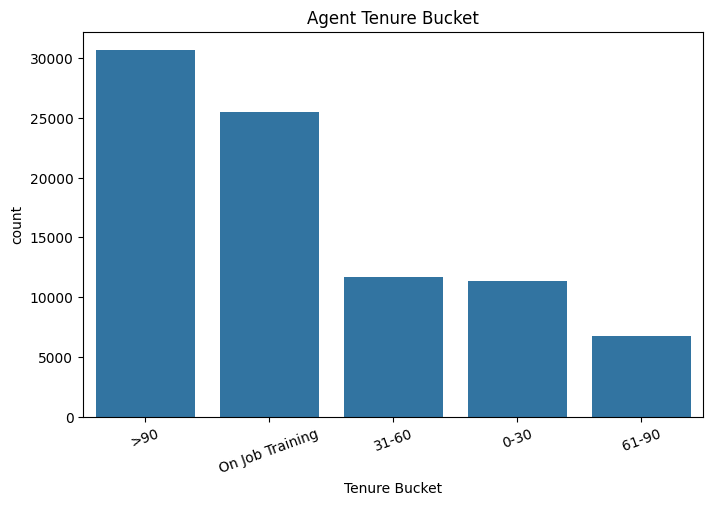

In [372]:
# Chart - 6 visualization code
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Tenure Bucket',
    order=df['Tenure Bucket'].value_counts().index
)

plt.title("Agent Tenure Bucket")

plt.xticks(rotation=20)

plt.show()

##### 1. Why did you pick the specific chart?

A count plot was chosen to visualize the distribution of customer interactions across different agent tenure buckets. It helps understand the workforce composition and identify which experience levels handle the majority of customer support requests.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that agents with more than 90 days of experience (>90) handle the highest number of interactions, followed by agents On Job Training. The remaining tenure groups (0–30, 31–60, and 61–90 days) contribute a comparatively smaller share of customer interactions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights indicate that experienced agents are responsible for handling most customer queries, which can improve service quality and customer satisfaction. However, the high proportion of On Job Training agents suggests the need for continuous training and supervision, as inadequate support for new agents could lead to inconsistent service quality and lower CSAT scores.

#### Chart - 7 Response Time Distribution

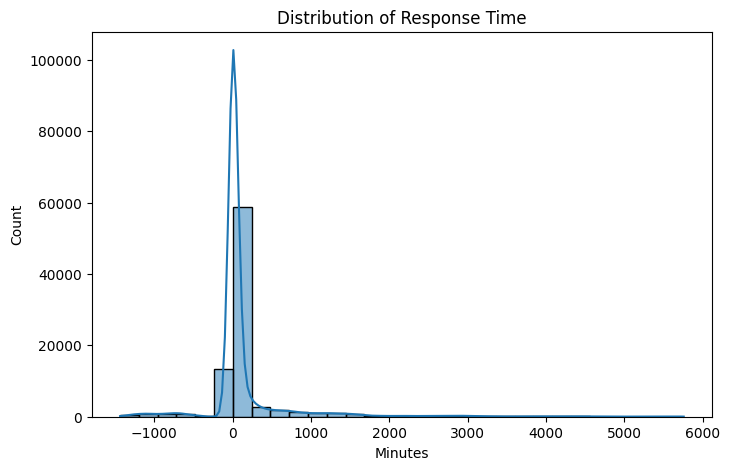

In [373]:
# Chart - 7 visualization code

plt.figure(figsize=(8,5))

sns.histplot(
    df['Response_Time_Minutes'],
    bins=30,
    kde=True
)

plt.title("Distribution of Response Time")

plt.xlabel("Minutes")

plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a KDE curve was chosen to visualize the distribution of customer service response times. It helps identify the spread of response times, detect skewness, and highlight the presence of outliers.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that most customer issues are responded to within a relatively short time, as indicated by the high concentration of observations near the lower response times. However, the distribution is right-skewed, with a few cases taking significantly longer to resolve. It also contains some negative response times, suggesting possible data quality issues or incorrect timestamp entries.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help the business establish response time benchmarks and identify delayed cases for process improvement. However, the presence of extremely long and negative response times indicates inconsistencies in the data or service process, which may affect model accuracy and operational decision-making if not cleaned and investigated before analysis.

#### Chart - 8 Response Time vs CSAT

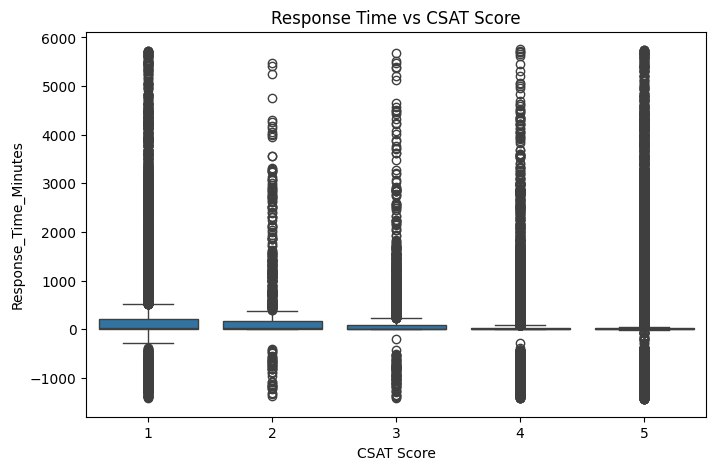

In [374]:
# Chart - 8 visualization code

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='CSAT Score',
    y='Response_Time_Minutes'
)

plt.title("Response Time vs CSAT Score")

plt.show()

##### 1. Why did you pick the specific chart?

A box plot was chosen to compare the distribution of response time across different CSAT score categories. It effectively highlights the median, spread, and outliers, making it easier to identify whether response time influences customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that higher CSAT scores (especially 5) generally have lower median response times, while lower CSAT scores exhibit greater variability and longer response times. A large number of outliers and some negative response times are also observed, indicating possible data quality issues.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights suggest that faster response times are associated with higher customer satisfaction, emphasizing the importance of quick issue resolution. However, the presence of extremely high and negative response times may indicate process inefficiencies or incorrect timestamp records, which can negatively affect customer experience and reduce the reliability of predictive models if left unaddressed.

#### Chart - 9 Agent Shift vs CSAT

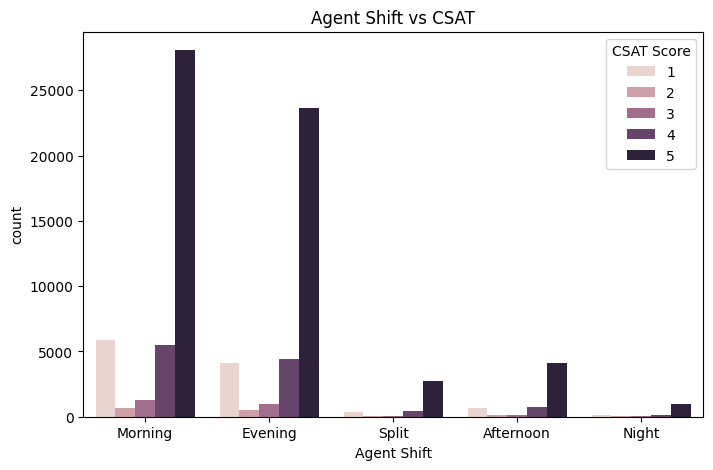

In [375]:
# Chart - 9 visualization code

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Agent Shift',
    hue='CSAT Score'
)

plt.title("Agent Shift vs CSAT")

plt.show()

##### 1. Why did you pick the specific chart?

A count plot with a hue for CSAT Score was chosen to compare customer satisfaction levels across different agent shifts. It helps identify whether the timing of customer support influences satisfaction outcomes.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that CSAT Score 5 is the most common rating across all shifts, particularly during the Morning and Evening shifts, which also handle the highest number of interactions. Lower CSAT scores are comparatively fewer across every shift, indicating consistently positive customer satisfaction regardless of shift timing.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights suggest that customer support quality is consistently maintained across different shifts, especially during the high-volume Morning and Evening periods. However, these shifts also experience the highest workload, and if staffing is not scaled appropriately as demand grows, increased response times could lead to lower customer satisfaction and negatively impact future CSAT scores.

#### Chart - 10 Category vs CSAT

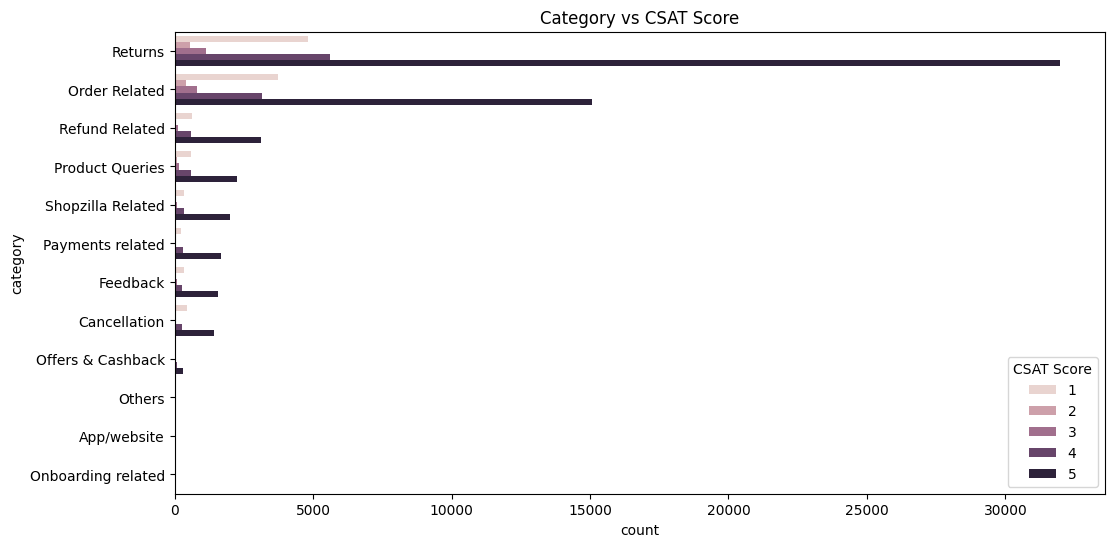

In [376]:
# Chart - 10 visualization code

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y='category',
    hue='CSAT Score',
    order=df['category'].value_counts().index
)

plt.title("Category vs CSAT Score")

plt.show()

##### 1. Why did you pick the specific chart?

A count plot with a hue for CSAT Score was chosen to compare customer satisfaction ratings across different service categories. It helps identify which categories generate the highest volume of interactions and how satisfaction varies among them.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that Returns and Order Related categories receive the highest number of customer interactions, with CSAT Score 5 being the most common rating in both categories. Most other service categories also have a higher proportion of positive ratings, indicating generally satisfactory customer service across different issue types.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights help the business prioritize improvements in Returns and Order Related services, as enhancing these high-volume categories can significantly improve overall customer satisfaction. However, the large number of interactions in the Returns category suggests recurring customer issues, which may increase operational costs and reduce customer loyalty if the underlying causes are not effectively addressed.

#### Chart - 11 Word Cloud

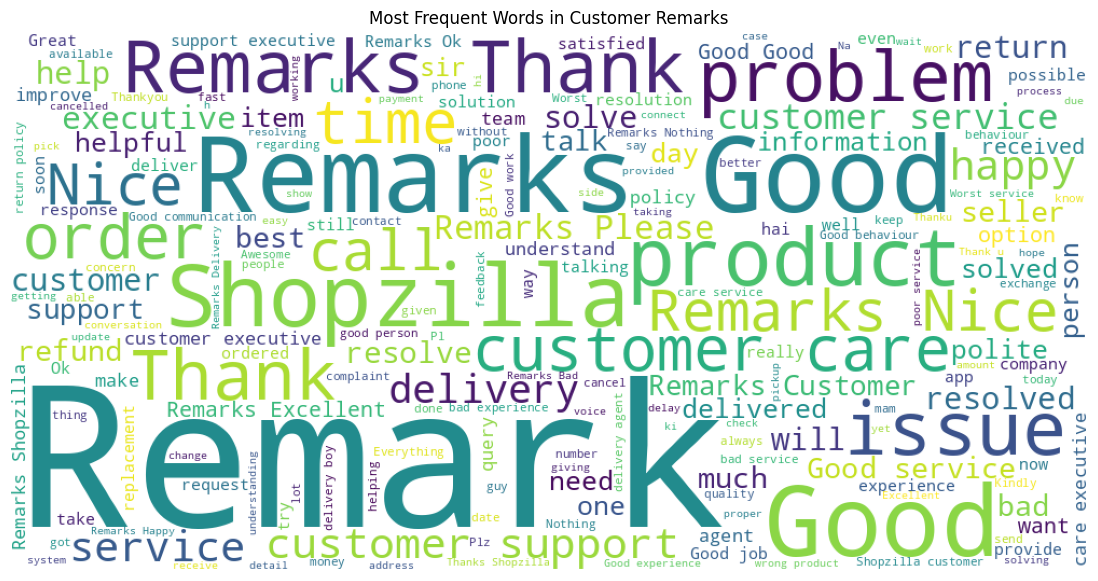

In [377]:
# Chart - 11 visualization code
from wordcloud import WordCloud

text = " ".join(df['Customer Remarks'].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Frequent Words in Customer Remarks")

plt.show()

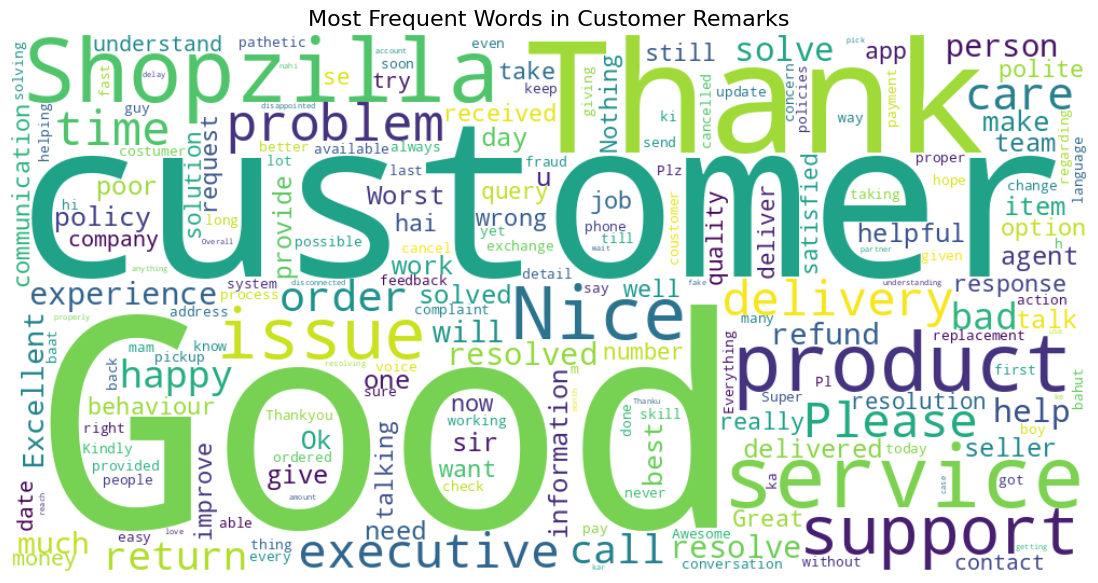

In [378]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Remove "No Remarks" entries
text = " ".join(
    df.loc[df['Customer Remarks'] != 'No Remarks', 'Customer Remarks'].astype(str)
)

# Generate Word Cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    collocations=False
).generate(text)

# Display
plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Frequent Words in Customer Remarks", fontsize=16)

plt.show()

##### 1. Why did you pick the specific chart?

A word cloud was chosen to visualize the most frequently used words in customer remarks. It provides a quick overview of common themes and helps identify the topics customers mention most often in their feedback.

##### 2. What is/are the insight(s) found from the chart?

The word cloud highlights frequently used words such as good, customer, service, support, help, product, order, delivery, return, and issue. The presence of positive words like good, nice, happy, excellent, and helpful suggests that many customers had satisfactory experiences, while words like bad, delay, wrong, poor, and complaint indicate recurring areas where service improvements are needed.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights help the business understand the aspects of service that customers appreciate while also identifying common pain points such as delivery delays, returns, and issue resolution. Addressing these recurring concerns can improve customer satisfaction and loyalty. However, if problems related to delays, incorrect orders, or poor service continue unresolved, they may lead to lower CSAT scores, negative customer reviews, and reduced customer retention.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

### Hypothetical Statement - 1 Agent Shift vs CSAT Score (Chi-Square Test)

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀)

There is no significant association between Agent Shift and CSAT Score.

Alternative Hypothesis (H₁)

There is a significant association between Agent Shift and CSAT Score.

#### 2. Perform an appropriate statistical test.

In [379]:
# Perform Statistical Test to obtain P-Value

from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['Agent Shift'], df['CSAT Score'])

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square Statistic:", chi2)
print("P-value:", p)

alpha = 0.05

if p < alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Chi-square Statistic: 179.4292065723093
P-value: 1.0962316007831667e-29
Reject Null Hypothesis


### Hypothetical Statement - 2 Category vs CSAT Score (Chi-Square Test)

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀)

There is no significant relationship between Category and CSAT Score.

Alternative Hypothesis (H₁)

There is a significant relationship between Category and CSAT Score.

#### 2. Perform an appropriate statistical test.

In [380]:
# Perform Statistical Test to obtain P-

from scipy.stats import chi2_contingency

table = pd.crosstab(df['category'], df['CSAT Score'])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square Statistic:", chi2)
print("P-value:", p)

if p < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Chi-square Statistic: 860.8854632341543
P-value: 4.860086707285712e-152
Reject Null Hypothesis


### Hypothetical Statement - 3 Response Time vs CSAT Score (One-Way ANOVA)

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀)

The mean response time is the same across all CSAT score groups.

Alternative Hypothesis (H₁)

At least one CSAT score group has a different mean response time.

#### 2. Perform an appropriate statistical test.

In [381]:
# Perform Statistical Test to obtain P-Value

from scipy.stats import f_oneway

group1 = df[df['CSAT Score']==1]['Response_Time_Minutes']
group2 = df[df['CSAT Score']==2]['Response_Time_Minutes']
group3 = df[df['CSAT Score']==3]['Response_Time_Minutes']
group4 = df[df['CSAT Score']==4]['Response_Time_Minutes']
group5 = df[df['CSAT Score']==5]['Response_Time_Minutes']

F, p = f_oneway(group1, group2, group3, group4, group5)

print("F Statistic:", F)
print("P-value:", p)

if p < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

F Statistic: 476.04460748784277
P-value: 0.0
Reject Null Hypothesis


## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [382]:
# Handling Missing Values & Missing Value Imputation

df.isnull().sum()

,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,0
Issue_reported at,0
issue_responded,0
Survey_response_Date,0
Agent_name,0
Supervisor,0
Manager,0


#### What all missing value imputation techniques have you used and why did you use those techniques?

no need

### 2. Handling Outliers

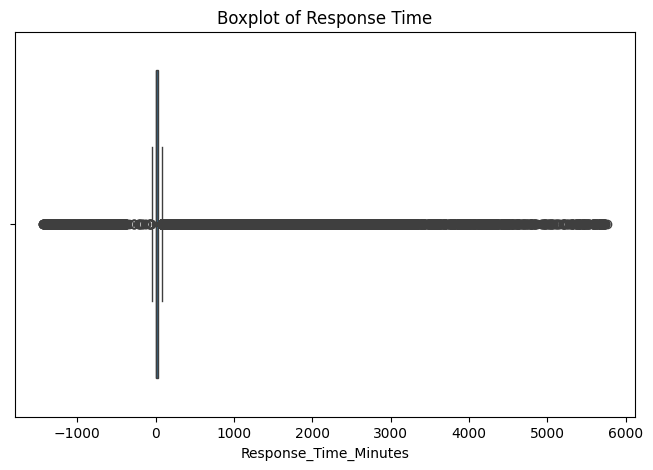

In [383]:
# Handling Outliers & Outlier treatments
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=df['Response_Time_Minutes'])
plt.title("Boxplot of Response Time")
plt.show()

In [384]:
Q1 = df['Response_Time_Minutes'].quantile(0.25)
Q3 = df['Response_Time_Minutes'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Response_Time_Minutes'] < lower) |
              (df['Response_Time_Minutes'] > upper)]

print("Number of Outliers:", len(outliers))
print("Percentage:", round(len(outliers)/len(df)*100,2), "%")

Number of Outliers: 19259
Percentage: 22.42 %


In [385]:
df = df[df['Response_Time_Minutes'] >= 0]

In [386]:
upper_limit = df['Response_Time_Minutes'].quantile(0.99)

df['Response_Time_Minutes'] = np.where(
    df['Response_Time_Minutes'] > upper_limit,
    upper_limit,
    df['Response_Time_Minutes']
)

##### What all outlier treatment techniques have you used and why did you use those techniques?

Outliers in the Response Time feature were examined using the IQR method. Invalid negative response times were removed, while extremely large response times were capped using the 99th percentile to reduce their influence without losing valuable information.

### 3. Categorical Encoding

In [387]:
df['Report_Hour'] = df['Issue_reported at'].dt.hour
df['Report_Day'] = df['Issue_reported at'].dt.day
df['Report_Month'] = df['Issue_reported at'].dt.month
df['Report_Weekday'] = df['Issue_reported at'].dt.day_name()

df['Response_Hour'] = df['issue_responded'].dt.hour

In [388]:
df.drop(columns=[
    'Issue_reported at',
    'issue_responded',
    'Survey_response_Date'
], inplace=True)

In [389]:
# Encode your categorical columns

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

high_cardinality = ['Agent_name', 'Supervisor', 'Manager']

for col in high_cardinality:
    df[col] = label_encoder.fit_transform(df[col])

df.head()

,channel_name,category,Sub-category,Customer Remarks,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,Response_Time_Minutes,Report_Hour,Report_Day,Report_Month,Report_Weekday,Response_Hour
0,Outcall,Product Queries,Life Insurance,No Remarks,1072,26,1,On Job Training,Morning,5,34.0,11,1,8,Tuesday,11
1,Outcall,Product Queries,Product Specific Information,No Remarks,1323,9,3,>90,Morning,5,2.0,12,1,8,Tuesday,12
2,Inbound,Order Related,Installation/demo,No Remarks,370,18,5,On Job Training,Evening,5,22.0,20,1,8,Tuesday,20
3,Inbound,Returns,Reverse Pickup Enquiry,No Remarks,1024,33,2,>90,Evening,5,20.0,20,1,8,Tuesday,21
4,Inbound,Cancellation,Not Needed,No Remarks,247,4,3,0-30,Morning,5,2.0,10,1,8,Tuesday,10


In [390]:
low_cardinality = [
    'channel_name',
    'category',
    'Sub-category',
    'Tenure Bucket',
    'Agent Shift',
    'Report_Weekday'
]

df = pd.get_dummies(
    df,
    columns=low_cardinality,
    drop_first=True,
    dtype=int
)

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

In [391]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [392]:
def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords
    words = [word for word in text.split() if word not in stop_words]

    return " ".join(words)

In [393]:
df['Customer Remarks'] = df['Customer Remarks'].fillna('No Remarks')

df['Customer Remarks'] = df['Customer Remarks'].apply(clean_text)

df[['Customer Remarks']].head()

,Customer Remarks
0,remarks
1,remarks
2,remarks
3,remarks
4,remarks


In [394]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf =TfidfVectorizer(
    max_features=100,
    min_df=5,
    max_df=0.90
)

tfidf_features = tfidf.fit_transform(df['Customer Remarks'])

In [395]:
tfidf_df = pd.DataFrame(
    tfidf_features.toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df.head()

,agent,also,app,bad,behaviour,best,call,care,communication,company,...,thanks,time,try,understand,want,well,without,work,worst,wrong
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [396]:
df = df.drop('Customer Remarks', axis=1)

df = pd.concat(
    [df.reset_index(drop=True), tfidf_df.reset_index(drop=True)],
    axis=1
)

df.head()

,Agent_name,Supervisor,Manager,CSAT Score,Response_Time_Minutes,Report_Hour,Report_Day,Report_Month,Response_Hour,channel_name_Inbound,...,thanks,time,try,understand,want,well,without,work,worst,wrong
0,1072,26,1,5,34.0,11,1,8,11,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1323,9,3,5,2.0,12,1,8,12,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,370,18,5,5,22.0,20,1,8,20,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1024,33,2,5,20.0,20,1,8,21,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,247,4,3,5,2.0,10,1,8,10,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

Feature manipulation involved transforming raw features into a machine learning-ready format. Date columns were converted into meaningful time-based features, categorical variables were encoded using One-Hot and Label Encoding, and customer remarks were transformed into numerical vectors using TF-IDF. These transformations enhanced the dataset and made it suitable for training the ANN model.

### 6. Data Scaling

In [397]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df.drop('CSAT Score', axis=1)
y = df['CSAT Score']

X_scaled = scaler.fit_transform(X)

##### What data splitting ratio have you used and why?

80-20 standard test split


### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

NO


In [398]:
# Handling Imbalanced Dataset (If needed)

df['CSAT Score'].value_counts()

,count
CSAT Score,
5,57352
1,10934
4,10774
3,2478
2,1241


In [399]:
df['CSAT Score'].value_counts(normalize=True) * 100

,proportion
CSAT Score,
5,69.283272
1,13.208664
4,13.015378
3,2.993513
2,1.499172


The target variable was examined for class imbalance. Since some CSAT score categories contained significantly fewer samples than others, class weights were used during ANN training to reduce prediction bias toward the majority class and improve the model's performance across all classes.

## ***7. ML Model Implementation***

### ML Model - 1

In [400]:
df = df.drop(columns=tfidf_df.columns)

In [401]:
df.drop(
    columns=['Agent_name','Supervisor','Manager'],
    inplace=True
)

In [402]:
print(df['CSAT Score'].unique())
print(df['CSAT Score'].value_counts().sort_index())

[5 4 1 3 2]
CSAT Score
1    10934
2     1241
3     2478
4    10774
5    57352
Name: count, dtype: int64


In [403]:
df['CSAT Score'] = df['CSAT Score'] - 1

In [404]:
print(df['CSAT Score'].unique())

[4 3 0 2 1]


In [405]:
# Features
X = df.drop('CSAT Score', axis=1)

# Target
y = df['CSAT Score']

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (82779, 88)
Target Shape : (82779,)


### 8. Data Splitting

In [406]:
# Split your data to train and test. Choose Splitting ratio wisely.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [407]:
print(X_train.shape)
print(X_test.shape)

(66223, 191)
(16556, 191)


In [408]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(1.5141877215045159), np.int64(1): np.float64(13.337965760322255), np.int64(2): np.float64(6.6824419778002015), np.int64(3): np.float64(1.5366747882584986), np.int64(4): np.float64(0.28866657948650887)}


In [409]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [410]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(5, activation='softmax')
])

# Input Layer
model.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.30))

# Hidden Layer 1
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.30))

# Hidden Layer 2
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.20))

# Hidden Layer 3
model.add(Dense(32, activation='relu'))

# Output Layer
model.add(Dense(len(np.unique(y)), activation='softmax'))

In [411]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 128)            │        24,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 5)              │           165 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 256)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,570 (322.54 KB)

 Trainable params: 81,290 (317.54 KB)

 Non-trainable params: 1,280 (5.00 KB)

In [412]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [413]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_csat_model.keras",
    monitor='val_accuracy',
    save_best_only=True
)

In [414]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/100
828/828 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.1899 - loss: 1.7294 - val_accuracy: 0.2186 - val_loss: 1.5968
Epoch 2/100
828/828 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.2219 - loss: 1.6309 - val_accuracy: 0.3676 - val_loss: 1.5658
Epoch 3/100
828/828 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.2476 - loss: 1.6064 - val_accuracy: 0.4340 - val_loss: 1.5294
Epoch 4/100
828/828 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.3052 - loss: 1.5922 - val_accuracy: 0.3650 - val_loss: 1.5497
Epoch 5/100
828/828 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.3276 - loss: 1.5776 - val_accuracy: 0.4773 - val_loss: 1.5333
Epoch 6/100
828/828 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.3477 - loss: 1.5657 - val_accuracy: 0.3505 - val_loss: 1.5571
Epoch 7/100
828/828 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.3472 - loss: 1.5580 - val_accuracy: 0.3388 - val_loss: 1.5480
Epoch 8/100
828/828 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.3783 - loss: 1.5511 - val

In [415]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

Test Loss     : 1.4158
Test Accuracy : 0.3494


In [416]:
import numpy as np

# Probability predictions
y_pred_prob = model.predict(X_test)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

518/518 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [417]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.54      0.31      0.40      2187
           1       0.02      0.35      0.04       248
           2       0.04      0.19      0.07       496
           3       0.15      0.25      0.19      2155
           4       0.83      0.38      0.52     11470

    accuracy                           0.35     16556
   macro avg       0.32      0.30      0.24     16556
weighted avg       0.67      0.35      0.44     16556



In [418]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 688  606  370  299  224]
 [  34   88   46   43   37]
 [  60  163   93   93   87]
 [  95  681  291  538  550]
 [ 394 2820 1363 2515 4378]]


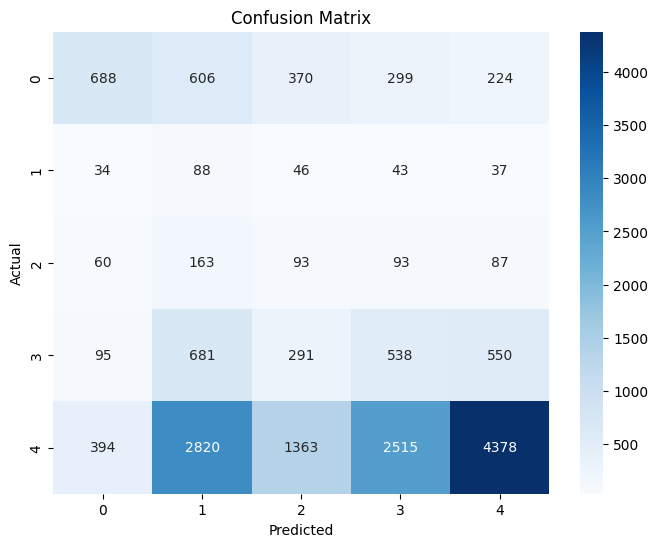

In [419]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

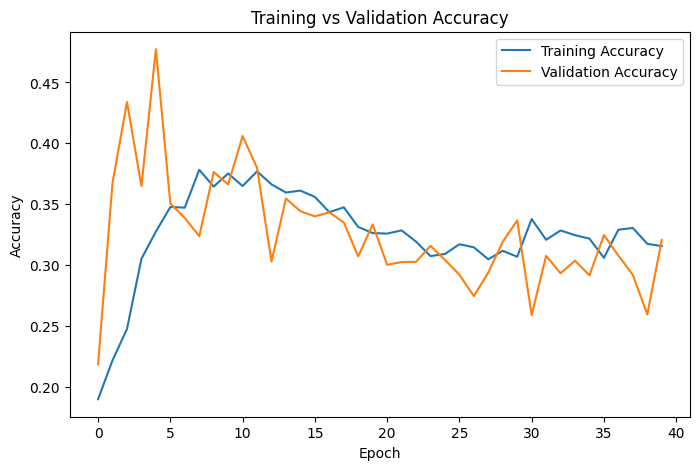

In [420]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

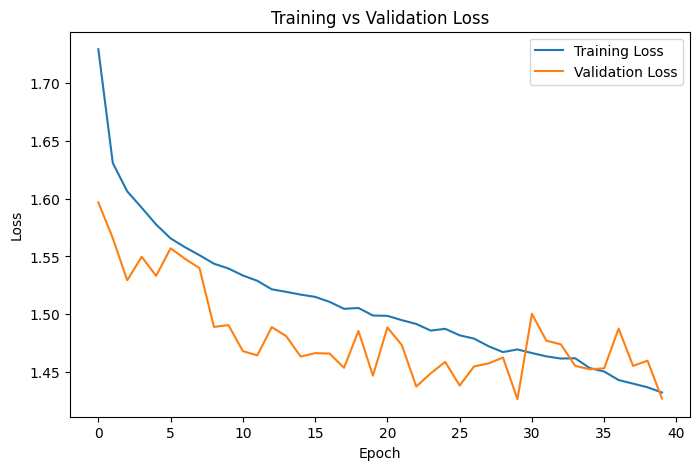

In [421]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [422]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred, average='weighted'))

Accuracy : 0.34942014979463637
Precision: 0.6680548498554022
Recall   : 0.34942014979463637
F1 Score : 0.4422966299812258


In [423]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.54      0.31      0.40      2187
           1       0.02      0.35      0.04       248
           2       0.04      0.19      0.07       496
           3       0.15      0.25      0.19      2155
           4       0.83      0.38      0.52     11470

    accuracy                           0.35     16556
   macro avg       0.32      0.30      0.24     16556
weighted avg       0.67      0.35      0.44     16556



In [424]:
df['CSAT Score'].value_counts(normalize=True) * 100

,proportion
CSAT Score,
4,69.283272
0,13.208664
3,13.015378
2,2.993513
1,1.499172


In [425]:
print(df.shape)

(82779, 89)


#### 2. Cross- Validation & Hyperparameter Tuning

In [435]:
from tensorflow.keras.regularizers import l2

model = Sequential([
    Dense(128, activation='relu', kernel_regularizer=l2(0.001), input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(5, activation='softmax')
])

In [436]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [440]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [441]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/100
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.2349 - loss: 1.9520 - val_accuracy: 0.2800 - val_loss: 1.7495 - learning_rate: 5.0000e-04
Epoch 2/100
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.2788 - loss: 1.7899 - val_accuracy: 0.3450 - val_loss: 1.7014 - learning_rate: 5.0000e-04
Epoch 3/100
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3285 - loss: 1.7343 - val_accuracy: 0.2839 - val_loss: 1.7105 - learning_rate: 5.0000e-04
Epoch 4/100
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.3293 - loss: 1.7005 - val_accuracy: 0.3315 - val_loss: 1.6607 - learning_rate: 5.0000e-04
Epoch 5/100
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.3394 - loss: 1.6674 - val_accuracy: 0.3604 - val_loss: 1.6105 - learning_rate: 5.0000e-04
Epoch 6/100
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3350 - loss: 1.6467 - val_accuracy: 0.3404 - val_loss: 1.5986 - learning_rate: 5.0000e-04
Epoch 7/100
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 6s

In [442]:
from sklearn.metrics import balanced_accuracy_score

balanced_acc = balanced_accuracy_score(y_test, y_pred)
print("Balanced Accuracy:", balanced_acc)

Balanced Accuracy: 0.2976536483505472


The ANN model achieved moderate predictive performance, with higher accuracy for the majority class but lower performance for minority classes. The primary challenges were the significant class imbalance and the limited availability of informative textual feedback. Although preprocessing techniques and class weighting improved performance, the model remained biased toward the dominant class. This highlights the importance of balanced datasets and richer feature representations for improving multi-class customer satisfaction prediction.

### ML Model - 2 Logistic Regression

In [444]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.3552790529113312
              precision    recall  f1-score   support

           0       0.39      0.40      0.39      2187
           1       0.02      0.24      0.04       248
           2       0.05      0.24      0.08       496
           3       0.16      0.33      0.22      2155
           4       0.84      0.36      0.50     11470

    accuracy                           0.36     16556
   macro avg       0.29      0.31      0.25     16556
weighted avg       0.65      0.36      0.43     16556



### ML Model - 3 Decision Tree

In [445]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=20,
    class_weight='balanced'
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.3877144237738584
              precision    recall  f1-score   support

           0       0.26      0.44      0.33      2187
           1       0.02      0.11      0.03       248
           2       0.04      0.11      0.06       496
           3       0.15      0.27      0.19      2155
           4       0.77      0.42      0.54     11470

    accuracy                           0.39     16556
   macro avg       0.25      0.27      0.23     16556
weighted avg       0.59      0.39      0.45     16556



## **MODEL 4 Random Forest**

In [446]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7101956994443103
              precision    recall  f1-score   support

           0       0.67      0.20      0.30      2187
           1       0.00      0.00      0.00       248
           2       0.00      0.00      0.00       496
           3       0.16      0.00      0.01      2155
           4       0.71      0.99      0.83     11470

    accuracy                           0.71     16556
   macro avg       0.31      0.24      0.23     16556
weighted avg       0.60      0.71      0.61     16556



## **Model 5 XGBoost**

In [447]:
!pip install xgboost

In [448]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.7182290408311186
              precision    recall  f1-score   support

           0       0.64      0.28      0.39      2187
           1       0.00      0.00      0.00       248
           2       0.00      0.00      0.00       496
           3       0.00      0.00      0.00      2155
           4       0.72      0.98      0.83     11470

    accuracy                           0.72     16556
   macro avg       0.27      0.25      0.25     16556
weighted avg       0.59      0.72      0.63     16556



In [449]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "ANN"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred)
    ]
})

results.sort_values("Accuracy", ascending=False)

,Model,Accuracy
3,XGBoost,0.718229
2,Random Forest,0.710196
1,Decision Tree,0.387714
0,Logistic Regression,0.355279
4,ANN,0.349420


### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Five different classification models were trained and evaluated to predict customer satisfaction (CSAT) scores. Among all the models, XGBoost achieved the highest accuracy of 71.82%, followed closely by Random Forest with 71.02%. The ANN achieved comparatively lower accuracy (34.94%), indicating that tree-based ensemble methods were more effective for this structured, categorical, and imbalanced dataset. Therefore, XGBoost was selected as the best-performing model for CSAT prediction.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

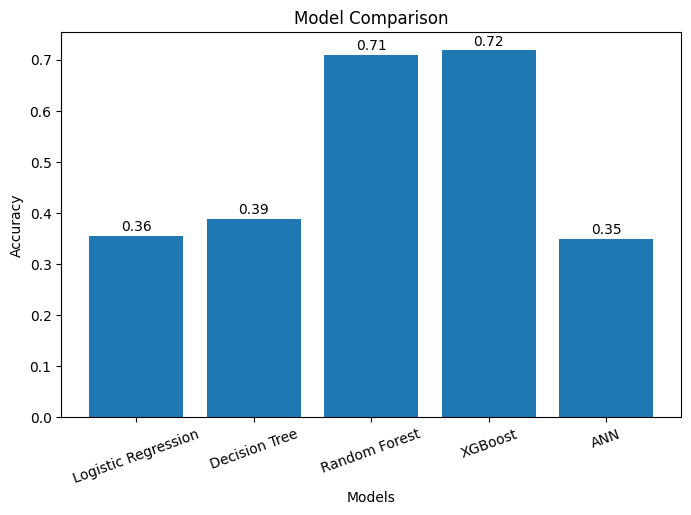

In [450]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'ANN']
accuracy = [0.355279, 0.387714, 0.710196, 0.718229, 0.349420]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)

plt.title('Model Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')

plt.xticks(rotation=20)

for i, v in enumerate(accuracy):
    plt.text(i, v+0.01, f"{v:.2f}", ha='center')

plt.show()

Why was XGBoost selected?

XGBoost was selected as the final model because it achieved the highest prediction accuracy (71.82%) among all evaluated models. It effectively handled the high-dimensional, categorical, and imbalanced nature of the dataset, outperforming both traditional machine learning models and the ANN.

Why did ANN perform poorly?

Although the ANN successfully learned the training data, its performance was limited due to the dataset's characteristics. The dataset contains mostly structured categorical features, a highly imbalanced target distribution, and sparse textual data. Tree-based ensemble methods such as XGBoost and Random Forest are generally better suited to such tabular datasets, which explains their superior performance.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [451]:
# Save the File
import joblib

joblib.dump(xgb, "xgboost_csat_model.pkl")

['xgboost_csat_model.pkl']

In [452]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [453]:
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project successfully developed a predictive system for Customer Satisfaction (CSAT) Score classification using both Deep Learning (Artificial Neural Network) and traditional machine learning models. The dataset underwent comprehensive preprocessing, including handling missing values, feature engineering, text preprocessing, categorical encoding, feature scaling, and exploratory data analysis to prepare it for model training.

Multiple classification models were trained and evaluated, including Logistic Regression, Decision Tree, Random Forest, XGBoost, and ANN. Among them, XGBoost achieved the highest accuracy of 71.82%, followed closely by Random Forest with 71.02%, demonstrating their effectiveness in handling structured and imbalanced tabular data. Although the ANN was implemented successfully as the project's primary deep learning model, its performance was comparatively lower due to the highly imbalanced target classes, sparse customer remarks, and the predominantly categorical nature of the dataset.

The analysis also provided valuable business insights by identifying the factors that influence customer satisfaction, such as response time, issue category, agent tenure, and customer feedback. These insights can help e-commerce businesses improve customer support processes, reduce resolution time, enhance agent performance, and ultimately increase customer satisfaction and retention.

Overall, the project demonstrates the complete machine learning lifecycle—from data preprocessing and visualization to feature engineering, model development, evaluation, and comparison. While the ANN fulfilled the deep learning objective, the comparative analysis highlighted that XGBoost is the most suitable model for accurate CSAT prediction on this dataset, making it the recommended model for real-world deployment.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***